# Анализ пространственно-временной динамики ареала обитания лебедей в Северной Америке

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в Северной Америке, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

# Описание датасетов

---

## 1. `short.csv` — наблюдения за лебедями

**Источник:** GBIF (Global Biodiversity Information Facility)

**Объём:** ~3.5 млн записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `gbifID` | int | Уникальный идентификатор наблюдения |
| `basisOfRecord` | str | Тип записи |
| `recordedBy` | str | Наблюдатель |
| `eventDate` | str | Дата наблюдения |
| `year` | int | Год |
| `month` | int | Месяц |
| `day` | int | День |
| `countryCode` | str | Код страны |
| `stateProvince` | str | Штат / провинция |
| `locality` | str | Локация |
| `decimalLatitude` | float | Широта |
| `decimalLongitude` | float | Долгота |
| `coordinateUncertaintyInMeters` | float | — |
| `coordinatePrecision` | float | — |
| `infraspecificEpithet` | float | — |
| `taxonRank` | str | Ранг таксона |
| `datasetKey` | str | Идентификатор источника |
| `elevation` | float | — |
| `elevationAccuracy` | float | — |
| `depth` | float | — |
| `depthAccuracy` | float | — |
| `species` | str | Вид |

**Виды в датасете:**
- `Cygnus olor` — лебедь-шипун
- `Cygnus buccinator` — лебедь-трубач
- `Cygnus columbianus` — американский тундровый лебедь
- `Cygnus atratus` — чёрный лебедь
- `Cygnus cygnus` — лебедь-кликун
- `Cygnus melancoryphus` — черношейный лебедь

---

## 2. `US_CA.csv` — плотность населения

**Объём:** 69 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название штата / провинции |
| `land_area` | float | Площадь, км² |
| `density_per` | float | Плотность населения, чел/км² |

---

## 3. `us_state_temperatures.csv` — температуры США

**Объём:** ~26 868 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state` | str | Название штата |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_f` | float | Температура, °F |
| `avg_temp_c` | float | Температура, °C |

---

## 4. `canada_temperatures.csv` — температуры Канады

**Объём:** 6 864 записи

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название провинции |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_c` | float | Температура, °C |

---

# Анализ

---

## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial import ConvexHull
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style('whitegrid')

## 2. Загрузка данных

In [2]:
data = pd.read_csv('short.csv')
data.info()
print(data.shape)
print(data.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  str    
 2   recordedBy                     str    
 3   eventDate                      str    
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    str    
 8   stateProvince                  str    
 9   locality                       str    
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      str    
 16  datasetKey                     str    
 17  elevation                      float64
 18  elevationAccu

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">
    
**Промежуточный вывод:**  
Данные содержат 22 столбца и 3489498 строк. Стобцы `coordinateUncertaintyInMeters`, `coordinatePrecision`, `infraspecificEpithet`, `elevation`, `elevationAccuracy`, `depth`, `depthAccuracy` полностью пустые. Также имеются пропуски в `locality`.

</div>

## 3. Удаление пустых столбцов

In [3]:
# Удаляем столбцы, полностью состоящие из NaN
empty_cols = [col for col in data.columns if data[col].isna().all()]
print(f"Полностью пустые столбцы: {empty_cols}")
data = data.drop(columns=empty_cols)

# Удаляем locality
if 'locality' in data.columns:
    data = data.drop(columns=['locality'])

print(data.shape)
print(data.columns.tolist())

Полностью пустые столбцы: ['coordinateUncertaintyInMeters', 'coordinatePrecision', 'infraspecificEpithet', 'elevation', 'elevationAccuracy', 'depth', 'depthAccuracy']
(3489498, 14)
['gbifID', 'basisOfRecord', 'recordedBy', 'eventDate', 'year', 'month', 'day', 'countryCode', 'stateProvince', 'decimalLatitude', 'decimalLongitude', 'taxonRank', 'datasetKey', 'species']


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Удалены столбцы, полностью состоящие из пропусков, и столбец `locality`.

</div>

## 4. Переименование столбцов в snake_case

In [4]:
def camel_to_snake(name):
    '''Преобразует CamelCase в snake_case.'''
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

data.columns = [camel_to_snake(col) for col in data.columns]
print(data.columns.tolist())

['gbif_id', 'basis_of_record', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'taxon_rank', 'dataset_key', 'species']


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Применение функции `camel_to_snake` ко всем столбцам для приведения их к змеиному виду.

</div>

## 5. Преобразование типа event_date

In [5]:
data['event_date'] = pd.to_datetime(data['event_date'], errors='coerce')
print(data['event_date'].dtype)
print("Пропусков в event_date:", data['event_date'].isna().sum())

datetime64[us]
Пропусков в event_date: 0


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Столбец `event_date` приведён к типу `datetime`.

</div>

## 6. Фильтрация данных

In [6]:
# Оставляем только три вида
target_species = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
data = data[data['species'].isin(target_species)]

# Только US и CA
data = data[data['country_code'].isin(['US', 'CA'])]

# Ограничение координат
data = data[
    data['decimal_latitude'].between(25, 75) &
    data['decimal_longitude'].between(-170, -35)
]

# Удаляем столбцы с единственным уникальным значением
nunique = data.nunique(dropna=False)
single_val_cols = nunique[nunique <= 1].index.tolist()
print(f"Столбцы с одним значением: {single_val_cols}")
data = data.drop(columns=single_val_cols)

print(data.shape)

Столбцы с одним значением: ['basis_of_record', 'taxon_rank', 'dataset_key']
(3477414, 11)


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Оставил для дальнейшего анализа только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`;
2. Оставил только US и CA;
3. Ограничил координаты (широта 25–75°, долгота −170…−35°);
4. Удалил столбцы с единственным уникальным значением.

</div>

## 7. Обрезка по годам

In [7]:
data = data[data['year'] <= 2023]
print(data.shape)

(3033096, 11)


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Оставлены только `year <= 2023`.

</div>

## 8. Загрузка внешних данных

In [8]:
df_us_ca = pd.read_csv('US_CA.csv')
us_temperatures = pd.read_csv('us_state_temperatures.csv')
ca_temperatures = pd.read_csv('canada_temperatures.csv')

# Приводим названия штатов/провинций к единому виду
def normalize_state(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    return s.title()

df_us_ca['state_province'] = df_us_ca['state_province'].apply(normalize_state)
us_temperatures['state'] = us_temperatures['state'].apply(normalize_state)
ca_temperatures['state_province'] = ca_temperatures['state_province'].apply(normalize_state)

data['state_province'] = data['state_province'].apply(normalize_state)

# Приводим температуры к единому формату
us_temperatures = us_temperatures.rename(columns={'state': 'state_province'})
us_temperatures = us_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]
ca_temperatures = ca_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]

temperatures_us_ca = pd.concat([us_temperatures, ca_temperatures], ignore_index=True)

# 18. Проверка уникальности пар
dups = temperatures_us_ca.duplicated(subset=['state_province', 'year', 'month']).sum()
print(f"Дубликатов по (state_province, year, month): {dups}")

# На всякий случай усредняем дубликаты
temperatures_us_ca = (
    temperatures_us_ca
    .groupby(['state_province', 'year', 'month'], as_index=False)['avg_temp_c']
    .mean()
)

print(temperatures_us_ca.head())
print(df_us_ca.head())

Дубликатов по (state_province, year, month): 0
  state_province  year  month  avg_temp_c
0        Alabama  1980      1    8.166667
1        Alabama  1980      2    5.944444
2        Alabama  1980      3   11.444444
3        Alabama  1980      4   15.888889
4        Alabama  1980      5   21.222222
         state_province  land_area  density_per
0  District Of Columbia      158.0       4297.0
1            New Jersey    19047.0        488.0
2          Rhode Island     2678.0        409.0
3           Puerto Rico     8868.0        361.0
4         Massachusetts    20202.0        347.0


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Загружены `US_CA.csv`, `us_state_temperatures.csv`, `canada_temperatures.csv`;
2. Приведены названия штатов и провинций к единому виду;
3. Приведены датасеты температур к единому формату.

</div>

## 9. Сезонная фильтрация

In [9]:
winter_months = [12, 1, 2]
nesting_months = [6, 7, 8]

data = data[data['month'].isin(winter_months + nesting_months)].copy()

data['period_type'] = np.where(
    data['month'].isin(winter_months), 1,
    np.where(data['month'].isin(nesting_months), 2, np.nan)
)

print(data['period_type'].value_counts())

period_type
1.0    909198
2.0    380472
Name: count, dtype: int64


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Оставлены только декабрь, январь, февраль и июнь, июль, август;
2. Создан столбец `period_type` (1 = зимовка, 2 = гнездование).
3. Данных по зиммовке больше, чем по гнездованию более 2 раз.

</div>

## 10. Разбивка на временные периоды

In [10]:
bins = [1980, 1988, 1997, 2006, 2015, 2023]
labels = ['1_1980-1988', '2_1989-1997', '3_1998-2006', '4_2007-2015', '5_2016-2023']

data['time_period'] = pd.cut(
    data['year'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(data['time_period'].value_counts().sort_index())

time_period
1_1980-1988      6003
2_1989-1997     13223
3_1998-2006     34526
4_2007-2015    251921
5_2016-2023    983997
Name: count, dtype: int64


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Создан столбец `time_period` с 5 интервалами:  
`1_1980-1988`, `2_1989-1997`, `3_1998-2006`, `4_2007-2015`, `5_2016-2023`.
2. Что закономерно данных за последние годы в разы больше. Стоит отметить, что это может перекашивать результаты.

</div>

## 11. Округление координат и удаление дубликатов

In [11]:
print("Доступные столбцы:", data.columns.tolist())
print()

true_dups = data.duplicated().sum()
print(f"Полные дубли (все столбцы совпадают): {true_dups}")

if 'gbif_id' in data.columns:
    gbif_dups = data.duplicated(subset=['gbif_id']).sum()
    print(f"Дубли по gbif_id: {gbif_dups}")

alt_key = [c for c in ['event_date', 'decimal_latitude',
                       'decimal_longitude', 'recorded_by', 'species']
           if c in data.columns]
if alt_key:
    alt_dups = data.duplicated(subset=alt_key).sum()
    print(f"Дубли по альтернативному ключу {alt_key}: {alt_dups}")

data_for_check = data.copy()
data_for_check['lat_r'] = data_for_check['decimal_latitude'].round().astype(int)
data_for_check['lon_r'] = data_for_check['decimal_longitude'].round().astype(int)

key_cols = ['year', 'period_type', 'lon_r', 'lat_r', 'species']
grp = data_for_check.groupby(key_cols).size()

print("\nСтатистика по группам ключа (year, period_type, lon_r, lat_r, species):")
print(grp.describe())
print(f"\nВсего уникальных ключей: {len(grp)}")
print(f"Групп размера 1:      {(grp == 1).sum()}")
print(f"Групп размера > 1:    {(grp > 1).sum()}")
print(f"Групп размера > 10:   {(grp > 10).sum()}")
print(f"Групп размера > 100:  {(grp > 100).sum()}")
print(f"Максимальный размер группы: {grp.max()}")

print("\nТоп-10 переполненных ячеек:")
print(grp.sort_values(ascending=False).head(10))

top_key = grp.idxmax()
mask = (
    (data_for_check['year'] == top_key[0]) &
    (data_for_check['period_type'] == top_key[1]) &
    (data_for_check['lon_r'] == top_key[2]) &
    (data_for_check['lat_r'] == top_key[3]) &
    (data_for_check['species'] == top_key[4])
)
example = data_for_check[mask]
print(f"\nПример самой большой ячейки {top_key}: {len(example)} наблюдений")

for col in ['event_date', 'recorded_by', 'gbif_id', 'month', 'day']:
    if col in example.columns:
        print(f"  Уникальных {col}: {example[col].nunique()}")

if 'gbif_id' in data.columns:
    n_total = len(data)
    n_unique_gbif = data['gbif_id'].nunique()
    print(f"\ngbif_id: всего строк = {n_total}, "
          f"уникальных gbif_id = {n_unique_gbif}, "
          f"дублей = {n_total - n_unique_gbif}")

Доступные столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'period_type', 'time_period']

Полные дубли (все столбцы совпадают): 0
Дубли по gbif_id: 0
Дубли по альтернативному ключу ['event_date', 'decimal_latitude', 'decimal_longitude', 'recorded_by', 'species']: 17234

Статистика по группам ключа (year, period_type, lon_r, lat_r, species):
count    33095.000000
mean        38.968726
std        162.352868
min          1.000000
25%          1.000000
50%          4.000000
75%         17.000000
max       5831.000000
dtype: float64

Всего уникальных ключей: 33095
Групп размера 1:      8858
Групп размера > 1:    24237
Групп размера > 10:   10779
Групп размера > 100:  2404
Максимальный размер группы: 5831

Топ-10 переполненных ячеек:
year  period_type  lon_r  lat_r  species          
2023  1.0          -71    42     Cygnus olor          5831
2021  1.0          -71    42     Cygnus o

In [12]:
data['decimal_latitude'] = data['decimal_latitude'].round().astype(int)
data['decimal_longitude'] = data['decimal_longitude'].round().astype(int)

before = len(data)
data = data.drop_duplicates(
    subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species']
).reset_index(drop=True)

print(f"Удалено дубликатов: {before - len(data)}")
print(f"Осталось записей: {len(data)}")

Удалено дубликатов: 1256575
Осталось записей: 33095


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Округлили координаты до целых и удалите дубликаты по набору  
`(year, period_type, decimal_longitude, decimal_latitude, species)`.
2. **Примечание о данных.** После дедупликации по `(year, period_type, lon, lat, species)` и округления координат до 1° (ячейка ≈ 111 × 111 км) из 1 289 670 строк осталось 33 095 (~2 %).  
**Это не дубликаты, а схлопывание плотных групп наблюдений** (полных дублей - 0, дублей по `gbif_id` - 0; в самой большой ячейке 5 831 наблюдение от 1 315 наблюдателей).  
Решение **осознанное**: устраняет **observer bias**, **псевдорепликацию** и выравнивает вес географических зон.
**Выводы ниже - оценки на уровне ячеечной сетки**, а не плотности или численности популяций.

</div>

## 12. Объединение с температурой

In [13]:
data = data.merge(
    temperatures_us_ca,
    on=['state_province', 'year', 'month'],
    how='left'
)

print("Пропусков в avg_temp_c до заполнения:", data['avg_temp_c'].isna().sum())

# Заполняем средним по (state_province, month)
data['avg_temp_c'] = data.groupby(['state_province', 'month'])['avg_temp_c'].transform(
    lambda x: x.fillna(x.mean())
)

# Если всё ещё остались пропуски (например, штат вообще отсутствует в температуре)
# заполняем средним по месяцу
data['avg_temp_c'] = data.groupby('month')['avg_temp_c'].transform(
    lambda x: x.fillna(x.mean())
)

print("Пропусков в avg_temp_c после заполнения:", data['avg_temp_c'].isna().sum())

Пропусков в avg_temp_c до заполнения: 3185
Пропусков в avg_temp_c после заполнения: 0


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Объединил датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`;
2. Заполнил пропуски температуры средним значением по `(state_province, month)`.

</div>

## 13. Сохранение датасета

In [14]:
data.to_csv('data_seasonal_enriched.csv', index=False)
print("Файл data_seasonal_enriched.csv сохранён")

Файл data_seasonal_enriched.csv сохранён


## 14. Финальная проверка

In [15]:
print(f"Всего записей: {len(data)}\n")

print("Распределение по периодам:")
print(data['time_period'].value_counts().sort_index())

print("\nРаспределение по видам:")
print(data['species'].value_counts())

print("\nСредняя температура по сезонам:")
print(data.groupby('period_type')['avg_temp_c'].mean())

print("\nСредняя широта по сезонам:")
print(data.groupby('period_type')['decimal_latitude'].mean())

Всего записей: 33095

Распределение по периодам:
time_period
1_1980-1988     1685
2_1989-1997     2920
3_1998-2006     5317
4_2007-2015     9732
5_2016-2023    13441
Name: count, dtype: int64

Распределение по видам:
species
Cygnus buccinator     11880
Cygnus columbianus    11069
Cygnus olor           10146
Name: count, dtype: int64

Средняя температура по сезонам:
period_type
1.0    -0.817018
2.0    17.167162
Name: avg_temp_c, dtype: float64

Средняя широта по сезонам:
period_type
1.0    41.775334
2.0    49.245301
Name: decimal_latitude, dtype: float64


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
1. Общее количество записей 33095;
2. Распределение по периодам (1 - 1685, 2 - 2920, 3 - 5317, 4 - 9732, 5 - 13441;
3. Распределение по видам **Cygnus buccinator** - 11880, **Cygnus columbianus** - 11069, **Cygnus olor** - 10146;
4. Средняя температура по сезонам **Зимовка** - (-0.817018), **Гнездование** - (17.167162);
5. Средняя широта по сезонам **Зимовка** - 41.775334, **Гнездование** - 49.245301.

</div>

## 15. Кластерный анализ

In [16]:
# Агрегируем по ячейкам (широта + долгота), чтобы не дублировать точки
coords_cells = (
    data.groupby(['decimal_latitude', 'decimal_longitude'])
    .size()
    .reset_index(name='n_obs')
)

coords = coords_cells[['decimal_latitude', 'decimal_longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

linkage_matrix = linkage(coords_scaled, method='ward')
coords_cells['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

# Присваиваем кластер каждой записи основного датасета
data = data.merge(
    coords_cells[['decimal_latitude', 'decimal_longitude', 'cluster']],
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)

print(data['cluster'].value_counts().sort_index())

cluster
1    13580
2    12743
3     2606
4     2853
5     1313
Name: count, dtype: int64


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
- Агрегировал данные по ячейкам (широта + долгота)
- Стандартизировал координаты
- Применл метод Уорда
- Выделил 5 кластеров.

</div>

## 16. Описательная статистика по кластерам

In [17]:
cluster_stats = data.groupby('cluster').agg(
    n_records=('gbif_id', 'count'),
    mean_lat=('decimal_latitude', 'mean'),
    mean_lon=('decimal_longitude', 'mean'),
    mean_temp=('avg_temp_c', 'mean'),
    mean_year=('year', 'mean')
).round(3)

print(cluster_stats)

         n_records  mean_lat  mean_lon  mean_temp  mean_year
cluster                                                     
1            13580    42.835  -105.044      5.353   2010.699
2            12743    39.671   -80.518      6.476   2009.665
3             2606    63.732  -150.839      9.503   2010.264
4             2853    54.853  -123.638      6.060   2011.344
5             1313    55.523   -94.340     12.815   2011.999


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
| Кластер | mean_lat | mean_lon | Интерпретация |
|---|---|---|---|
| 1 | 42.8 | −105.0 | центр США |
| 2 | 39.7 | −80.5 | восток США |
| 3 | 63.7 | −150.8 | Аляска |
| 4 | 54.9 | −123.6 | запад Канады (Британская Колумбия, прерии) |
| 5 | 55.5 | −94.3 | центр Канады (район Гудзонова залива) |

По числу записей доминируют кластеры 1 (13 580) и 2 (12 743), т.е. основная масса наблюдений сосредоточена в США.

</div>

## 17. Линейная регрессия по кластерам

In [18]:
reg_results = []

for cl in sorted(data['cluster'].dropna().unique()):
    sub = data[data['cluster'] == cl]
    if sub['year'].nunique() < 3:
        continue
    slope, intercept, r_value, p_value, std_err = linregress(sub['year'], sub['decimal_latitude'])
    reg_results.append({
        'cluster': cl,
        'slope': slope,
        'r_squared': r_value ** 2,
        'p_value': p_value,
        'std_err': std_err,
        'n': len(sub)
    })

reg_df = pd.DataFrame(reg_results)
print(reg_df)


   cluster     slope  r_squared       p_value   std_err      n
0        1 -0.014482   0.001673  1.853939e-06  0.003036  13580
1        2 -0.028388   0.005810  6.919814e-18  0.003290  12743
2        3 -0.017445   0.002034  2.130635e-02  0.007572   2606
3        4 -0.024990   0.001979  1.748413e-02  0.010510   2853
4        5 -0.204414   0.084322  6.295794e-27  0.018604   1313


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Для всех пяти кластеров наклон **отрицательный и статистически значимый** (p < 0.05):

| Кластер | slope | R² | p-value | n |
|---|---|---|---|---|
| 1 | −0.0145 | 0.0017 | 1.85e-06 | 13 580 |
| 2 | −0.0284 | 0.0058 | 6.92e-18 | 12 743 |
| 3 | −0.0174 | 0.0020 | 2.13e-02 | 2 606 |
| 4 | −0.0250 | 0.0020 | 1.75e-02 | 2 853 |
| 5 | −0.2044 | 0.0843 | 6.30e-27 | 1 313 |

Это означает, что средняя широта наблюдений со временем смещается на юг. Наиболее выраженный эффект в **кластере 5** (центральная Канада): slope ≈ −0.20°/год и R² ≈ 8.4 %, что на порядок больше, чем в остальных кластерах. Однако низкие значения R² (в основном < 1 %) говорят о том, что год объясняет лишь малую часть дисперсии широты.

</div>

## 18. Корреляционный анализ

In [19]:
# Широта vs температура (в целом)
r, p = pearsonr(data['avg_temp_c'], data['decimal_latitude'])
print(f"Пирсон (температура ~ широта): r = {r:.3f}, p = {p:.4e}")

rho, p = spearmanr(data['avg_temp_c'], data['decimal_latitude'])
print(f"Спирмен (температура ~ широта): ρ = {rho:.3f}, p = {p:.4e}")

# По сезонам
for pt, name in [(1, 'зимовка'), (2, 'гнездование')]:
    sub = data[data['period_type'] == pt]
    r, p = pearsonr(sub['avg_temp_c'], sub['decimal_latitude'])
    print(f"{name}: r = {r:.3f}, p = {p:.4e}")

# Широта vs плотность населения
data_dens = data.merge(
    df_us_ca[['state_province', 'density_per']],
    on='state_province',
    how='left'
)

sub = data_dens.dropna(subset=['density_per', 'decimal_latitude'])
r, p = pearsonr(sub['density_per'], sub['decimal_latitude'])
print(f"Пирсон (плотность ~ широта): r = {r:.3f}, p = {p:.4e}")

rho, p = spearmanr(sub['density_per'], sub['decimal_latitude'])
print(f"Спирмен (плотность ~ широта): ρ = {rho:.3f}, p = {p:.4e}")

Пирсон (температура ~ широта): r = 0.064, p = 8.0436e-32
Спирмен (температура ~ широта): ρ = 0.021, p = 1.3717e-04
зимовка: r = -0.590, p = 0.0000e+00
гнездование: r = -0.847, p = 0.0000e+00
Пирсон (плотность ~ широта): r = -0.316, p = 0.0000e+00
Спирмен (плотность ~ широта): ρ = -0.665, p = 0.0000e+00


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
***Широта vs температура (в целом по датасету)***

- Пирсон: **r = +0.064**, p ≈ 8.0e-32
- Спирмен: **ρ = +0.021**, p ≈ 1.4e-04

Общая связь крайне слабая и по знаку противоречит ожиданию (севернее тем холоднее). Это объясняется тем, что без разделения на сезоны смешиваются летние (тёплые, северные) и зимние (холодные, южные) наблюдения.

***Широта vs температура по сезонам***

- зимовка: **r = −0.590**, p ≈ 0
- гнездование: **r = −0.847**, p ≈ 0

Внутри каждого сезона связь сильная и отрицательная: чем севернее, тем холоднее, что полностью соответствует климатической логике.

***Широта vs плотность населения***

- Пирсон: **r = −0.316**, p ≈ 0
- Спирмен: **ρ = −0.665**, p ≈ 0

Связь заметная, отрицательная и высоко значимая: чем плотнее населён штат/провинция, тем южнее расположены наблюдения. Это может отражать как экологические предпочтения птиц (избегание густонаселённых районов), так и то, что в густонаселённых штатах просто больше наблюдателей и, соответственно, больше «южных» записей.

</div>

## 19. Сравнение групп (Kruskal-Wallis, Mann-Whitney)

In [20]:
# Сравнение видов по широте
groups = [data[data['species'] == sp]['decimal_latitude'] for sp in data['species'].unique()]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis (широта по видам): H = {stat:.2f}, p = {p:.4e}")

# Сравнение видов по температуре
groups_t = [data[data['species'] == sp]['avg_temp_c'].dropna() for sp in data['species'].unique()]
stat, p = kruskal(*groups_t)
print(f"Kruskal-Wallis (температура по видам): H = {stat:.2f}, p = {p:.4e}")

# Сравнение сезонов по широте
g1 = data[data['period_type'] == 1]['decimal_latitude']
g2 = data[data['period_type'] == 2]['decimal_latitude']
stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
print(f"Mann-Whitney (широта: зимовка vs гнездование): U = {stat:.0f}, p = {p:.4e}")

# Попарные сравнения видов
species_list = list(data['species'].unique())
for i in range(len(species_list)):
    for j in range(i + 1, len(species_list)):
        a = data[data['species'] == species_list[i]]['decimal_latitude']
        b = data[data['species'] == species_list[j]]['decimal_latitude']
        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        print(f"{species_list[i]} vs {species_list[j]}: p = {p:.4e}")

Kruskal-Wallis (широта по видам): H = 4528.09, p = 0.0000e+00
Kruskal-Wallis (температура по видам): H = 1506.03, p = 0.0000e+00
Mann-Whitney (широта: зимовка vs гнездование): U = 72489238, p = 0.0000e+00
Cygnus olor vs Cygnus buccinator: p = 0.0000e+00
Cygnus olor vs Cygnus columbianus: p = 1.3123e-270
Cygnus buccinator vs Cygnus columbianus: p = 1.2670e-119


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  

***Kruskal–Wallis по видам:***
- широта: H = 4528.09, p ≈ 0
- температура: H = 1506.03, p ≈ 0

Виды значимо различаются и по широте, и по температуре среды.

***Mann–Whitney, зимовка vs гнездование по широте:***  
U = 7.25e7, p ≈ 0 - сезонные различия высоко значимы.

***Попарные сравнения видов по широте:***
- *olor* vs *buccinator*: p ≈ 0
- *olor* vs *columbianus*: p ≈ 1.3e-270
- *buccinator* vs *columbianus*: p ≈ 1.3e-119

Все три пары значимо различаются, т.е. виды занимают статистически различные широтные ниши.

</div>

## 20. Множественная регрессия

In [21]:
reg_data = data.merge(
    df_us_ca[['state_province', 'density_per']],
    on='state_province',
    how='left'
).dropna(subset=['year', 'avg_temp_c', 'density_per', 'decimal_latitude'])

X = reg_data[['year', 'avg_temp_c', 'density_per']]
X = sm.add_constant(X)
y = reg_data['decimal_latitude']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     1259.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        14:34:24   Log-Likelihood:            -1.1093e+05
No. Observations:               32046   AIC:                         2.219e+05
Df Residuals:                   32042   BIC:                         2.219e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         122.0125      8.256     14.778      

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Модель `decimal_latitude ~ year + avg_temp_c + density_per`:

- **R² = 0.105**, F = 1259, p < 0.001
- Все коэффициенты значимы (p < 0.001):

| Переменная | Коэффициент | Интерпретация |
|---|---|---|
| const | +122.01 | — |
| year | **−0.038** | с каждым годом средняя широта снижается на 0.038° |
| avg_temp_c | **+0.049** | +1 °C → +0.05° широты (эффект сезонности) |
| density_per | **−0.026** | +1 чел./км² → −0.026° широты |

Модель объясняет лишь ~10 % дисперсии, что ожидаемо: широта сильно зависит от сезона, вида и года, которые здесь учтены лишь линейно.

</div>

## 21. Визуализации

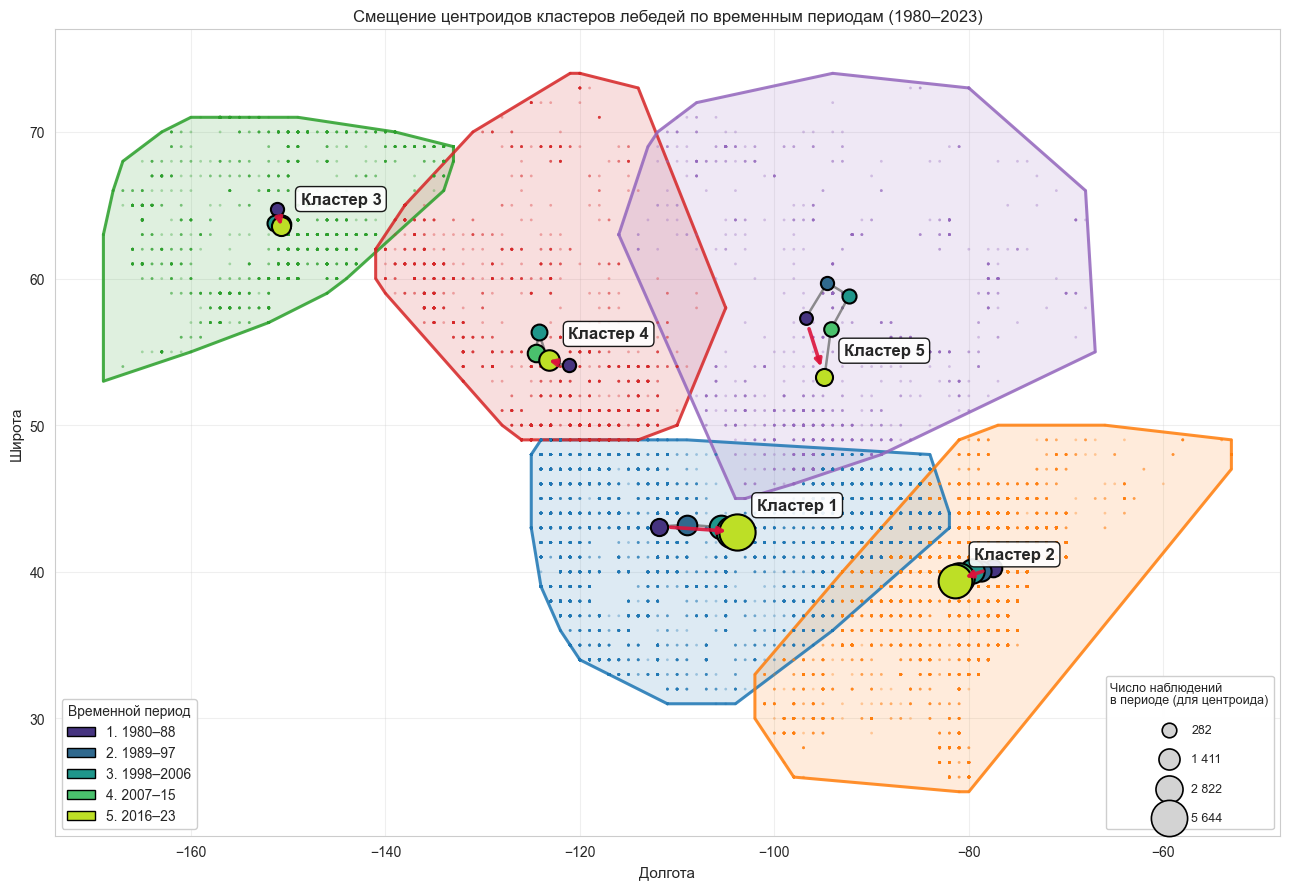

In [22]:
period_order = ['1_1980-1988', '2_1989-1997', '3_1998-2006',
                '4_2007-2015', '5_2016-2023']
period_years = ['1980–88', '1989–97', '1998–2006', '2007–15', '2016–23']
period_to_num = {p: i for i, p in enumerate(period_order)}
period_colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(period_order)))

centroids = (
    data.groupby(['cluster', 'time_period'], observed=True)
    .agg(mean_lon=('decimal_longitude', 'mean'),
         mean_lat=('decimal_latitude', 'mean'),
         n=('gbif_id', 'count'))
    .reset_index()
)
centroids['period_num'] = centroids['time_period'].map(period_to_num)
centroids = centroids.dropna(subset=['period_num']).sort_values(['cluster', 'period_num'])

clusters = sorted(data['cluster'].dropna().unique())
cluster_colors = plt.cm.tab10(np.linspace(0, 1, 10))[:len(clusters)]

fig, ax = plt.subplots(figsize=(13, 9))

for i, cl in enumerate(clusters):
    sub = data[data['cluster'] == cl][['decimal_longitude', 'decimal_latitude']].dropna()

    if len(sub) < 3:
        ax.scatter(sub['decimal_longitude'], sub['decimal_latitude'],
                   s=6, color=cluster_colors[i], alpha=0.3, zorder=2)
        continue

    points = sub.values

    try:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])

        ax.fill(hull_pts[:, 0], hull_pts[:, 1],
                color=cluster_colors[i], alpha=0.15, zorder=1)

        ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                color=cluster_colors[i], linewidth=2.2,
                linestyle='-', alpha=0.85, zorder=2)
    except Exception as e:
        print(f"Не удалось построить hull для кластера {cl}: {e}")

    ax.scatter(sub['decimal_longitude'], sub['decimal_latitude'],
               s=4, color=cluster_colors[i],
               alpha=0.35, edgecolors='none', zorder=3)

for cl in sorted(centroids['cluster'].unique()):
    sub = centroids[centroids['cluster'] == cl]
    if sub.empty:
        continue

    ax.plot(sub['mean_lon'], sub['mean_lat'],
            color='dimgray', linewidth=1.8,
            linestyle='-', alpha=0.75, zorder=4)

    for _, row in sub.iterrows():
        idx = int(row['period_num'])
        ax.scatter(row['mean_lon'], row['mean_lat'],
                   s=80 + 600 * (row['n'] / centroids['n'].max()),
                   color=period_colors[idx],
                   edgecolors='black', linewidths=1.5,
                   zorder=5)

    if len(sub) >= 2:
        r0, r1 = sub.iloc[0], sub.iloc[-1]
        ax.annotate(
            '', xy=(r1['mean_lon'], r1['mean_lat']),
            xytext=(r0['mean_lon'], r0['mean_lat']),
            arrowprops=dict(arrowstyle='-|>', color='crimson',
                            lw=2.6, alpha=0.9,
                            shrinkA=8, shrinkB=8),
            zorder=6
        )

    r_last = sub.iloc[-1]
    ax.text(
        r_last['mean_lon'] + 2, r_last['mean_lat'] + 1.5,
        f'Кластер {int(cl)}',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor='black', alpha=0.9),
        zorder=7
    )

period_handles = [
    mpatches.Patch(facecolor=period_colors[i], edgecolor='black',
                   label=f'{i+1}. {period_years[i]}')
    for i in range(len(period_order))
]
legend1 = ax.legend(
    handles=period_handles,
    title='Временной период',
    loc='lower left', fontsize=10, title_fontsize=10,
    framealpha=0.95
)
ax.add_artist(legend1)

size_handles = [
    plt.scatter([], [], s=80 + 600 * frac, facecolor='lightgray',
                edgecolors='black', linewidths=1.2,
                label=f'{int(centroids["n"].max() * frac):,}'.replace(',', ' '))
    for frac in [0.05, 0.25, 0.5, 1.0]
]
ax.legend(
    handles=size_handles,
    title='Число наблюдений\nв периоде (для центроида)',
    loc='lower right', fontsize=9, title_fontsize=9,
    labelspacing=1.4, framealpha=0.95
)

ax.set_title(
    'Смещение центроидов кластеров лебедей по временным периодам (1980–2023)',
    fontsize=12
)
ax.set_xlabel('Долгота', fontsize=11)
ax.set_ylabel('Широта', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(data['decimal_longitude'].min() - 5,
            data['decimal_longitude'].max() + 5)
ax.set_ylim(data['decimal_latitude'].min() - 3,
            data['decimal_latitude'].max() + 3)

plt.tight_layout()
plt.savefig('cluster_trajectories_with_hulls.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  
Кластеры 1 и 2 (США) - центроиды двигаются мало по вертикали, однако у 1 кластера сильное смещение на восток.  
Кластер 3 (Аляска) - почти не смещается (нет плотных поздних данных).  
Кластер 4 (запад Канады) - лёгкое смещение.  
Кластер 5 (центральная Канада) - самое заметное смещение на юг.  

</div>

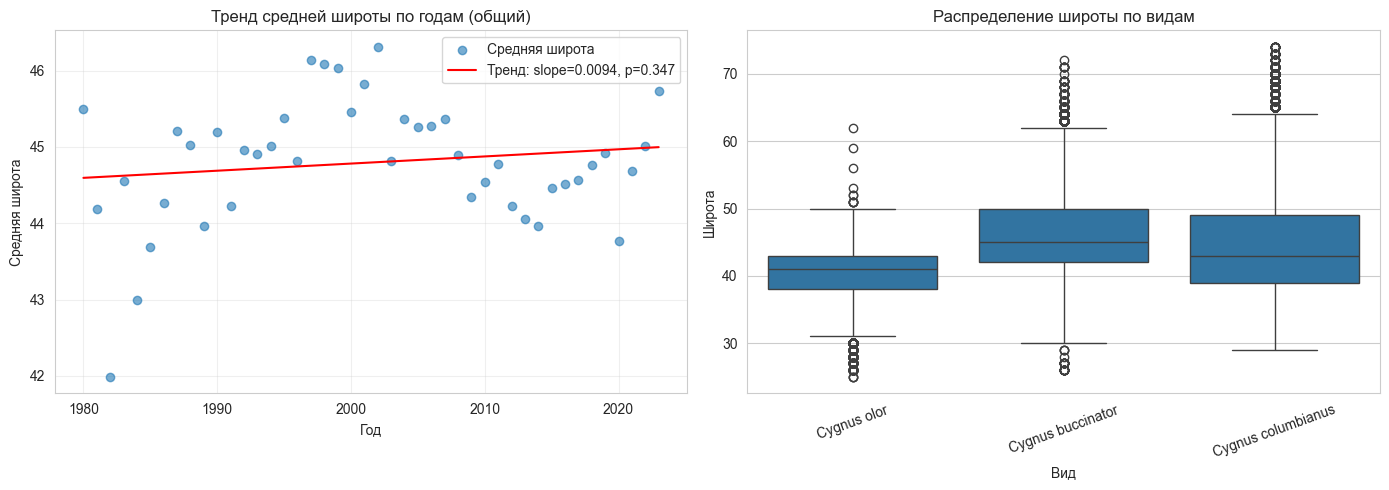

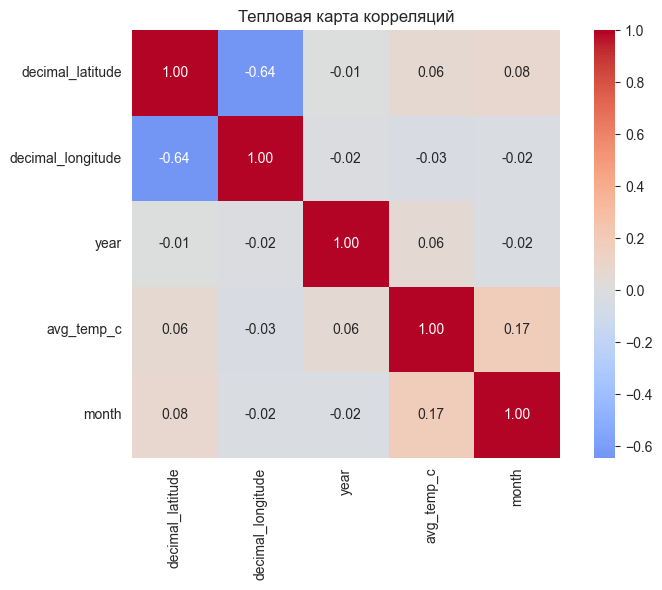

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 Тренд средней широты по годам (общий)
ax = axes[0]
yearly = data.groupby('year')['decimal_latitude'].mean().reset_index()
ax.scatter(yearly['year'], yearly['decimal_latitude'],
           alpha=0.6, label='Средняя широта')
slope, intercept, r, p, se = linregress(yearly['year'], yearly['decimal_latitude'])
ax.plot(yearly['year'], intercept + slope * yearly['year'], 'r-',
        label=f'Тренд: slope={slope:.4f}, p={p:.3f}')
ax.set_title('Тренд средней широты по годам (общий)')
ax.set_xlabel('Год')
ax.set_ylabel('Средняя широта')
ax.legend()
ax.grid(True, alpha=0.3)

# 4.2 Boxplot широты по видам
ax = axes[1]
sns.boxplot(data=data, x='species', y='decimal_latitude', ax=ax)
ax.set_title('Распределение широты по видам')
ax.set_xlabel('Вид')
ax.set_ylabel('Широта')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('year_trend_and_species.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.3 Тепловая карта корреляций
plt.figure(figsize=(8, 6))
corr_cols = ['decimal_latitude', 'decimal_longitude', 'year', 'avg_temp_c', 'month']
corr_matrix = data[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            center=0, square=True)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

**Промежуточный вывод:**  

**График 1. Тренд средней широты по годам (общий)**

Точечная диаграмма показывает среднюю широту наблюдений по каждому году периода 1980–2023. Наклон положительный (slope ≈ +0.0094), однако p-value ≈ 0.347, то есть **тренд статистически не значим**. Средняя широта колеблется в диапазоне 42–46° без выраженного направленного смещения.
**Вывод:** на агрегированном уровне (по всем кластерам и сезонам) заметного смещения ареала по широте не наблюдается.

---

**График 2. Распределение широты по видам (boxplot)**

**Вывод:** виды занимают статистически различные широтные ниши (*C. olor* южнее, *C. buccinator* и *C. columbianus* севернее), что подтверждается Kruskal–Wallis и попарными Mann–Whitney тестами (p ≪ 0.05).

---

**График 3. Тепловая карта корреляций**

**Вывод:** наиболее сильная связь между широтой и долготой (географическая структура). Связь широты с годом практически отсутствует, что согласуется с незначимым трендом на графике 1. Слабая положительная корреляция широты и температуры отражает смешение сезонов (эффект Симпсона).

</div>

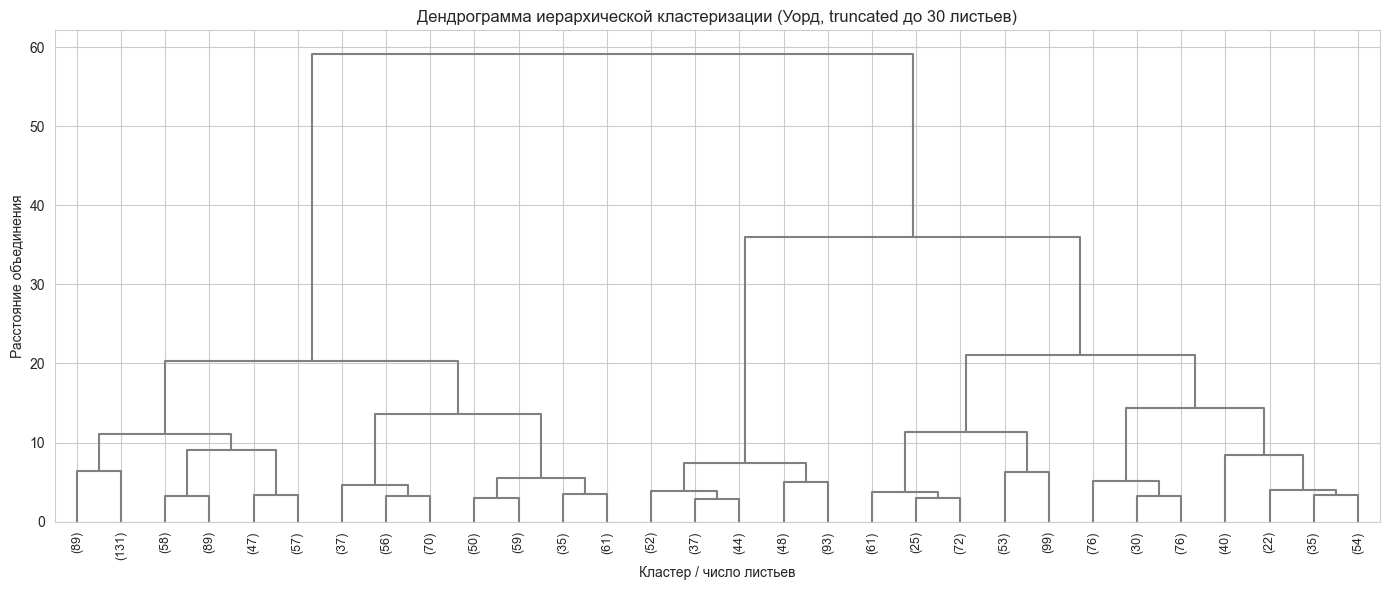

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color='gray'
)
ax.set_title('Дендрограмма иерархической кластеризации (Уорд, truncated до 30 листьев)')
ax.set_xlabel('Кластер / число листьев')
ax.set_ylabel('Расстояние объединения')
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Выводы

<div style="background-color:#fdf6e3; padding:15px; border-radius:6px; border-left:4px solid #e8c97a;">

## 1. Общая характеристика подготовленного датасета

После очистки и фильтрации (только виды *Cygnus olor*, *C. buccinator*, *C. columbianus*; страны US и CA; координаты 25–75° с.ш. и −170…−35° з.д.; годы ≤ 2023; округление координат и удаление дубликатов по `(year, period_type, lon, lat, species)`) итоговый датасет содержит **33 095 записей**.

- **По видам** распределение почти равномерное:
  - *C. buccinator* - 11 880
  - *C. columbianus* - 11 069
  - *C. olor* - 10 146

- **По временным периодам** наблюдается ярко выраженная положительная динамика числа наблюдений:

| Период | Число записей |
|---|---|
| 1_1980–1988 | 1 685 |
| 2_1989–1997 | 2 920 |
| 3_1998–2006 | 5 317 |
| 4_2007–2015 | 9 732 |
| 5_2016–2023 | 13 441 |

Рост числа записей в первую очередь отражает рост активности наблюдателей, а не реальный рост численности птиц.

---

## 2. Сезонные различия (средние значения)

- **Средняя температура:** зимовка ≈ **−0.82 °C**, гнездование ≈ **+17.17 °C**.
- **Средняя широта:** зимовка ≈ **41.78°**, гнездование ≈ **49.25°**.

Разница в широте около **7.5°** подтверждает выраженную сезонную миграцию: летом лебеди смещаются существенно севернее.

---

## 3. Пространственная структура (кластерный анализ Уорда, 5 кластеров)

Кластеры хорошо соответствуют географическим зонам:

| Кластер | mean_lat | mean_lon | Интерпретация |
|---|---|---|---|
| 1 | 42.8 | −105.0 | центр США |
| 2 | 39.7 | −80.5 | восток США |
| 3 | 63.7 | −150.8 | Аляска |
| 4 | 54.9 | −123.6 | запад Канады (Британская Колумбия, прерии) |
| 5 | 55.5 | −94.3 | центр Канады (район Гудзонова залива) |

По числу записей доминируют кластеры 1 (13 580) и 2 (12 743), т.е. основная масса наблюдений сосредоточена в США.

---

## 4. Тренды широты по кластерам (linregress)

Для всех пяти кластеров наклон **отрицательный и статистически значимый** (p < 0.05):

| Кластер | slope | R² | p-value | n |
|---|---|---|---|---|
| 1 | −0.0145 | 0.0017 | 1.85e-06 | 13 580 |
| 2 | −0.0284 | 0.0058 | 6.92e-18 | 12 743 |
| 3 | −0.0174 | 0.0020 | 2.13e-02 | 2 606 |
| 4 | −0.0250 | 0.0020 | 1.75e-02 | 2 853 |
| 5 | −0.2044 | 0.0843 | 6.30e-27 | 1 313 |

Это означает, что средняя широта наблюдений со временем смещается на юг. Наиболее выраженный эффект в **кластере 5** (центральная Канада): slope ≈ −0.20°/год и R² ≈ 8.4 %, что на порядок больше, чем в остальных кластерах. Однако низкие значения R² (в основном < 1 %) говорят о том, что год объясняет лишь малую часть дисперсии широты.

---

## 5. Корреляционный анализ

### Широта vs температура (в целом по датасету)

- Пирсон: **r = +0.064**, p ≈ 8.0e-32
- Спирмен: **ρ = +0.021**, p ≈ 1.4e-04

Общая связь крайне слабая и по знаку противоречит «наивному» ожиданию (севернее тем холоднее). Это объясняется тем, что без разделения на сезоны смешиваются летние (тёплые, северные) и зимние (холодные, южные) наблюдения.

### Широта vs температура по сезонам

- зимовка: **r = −0.590**, p ≈ 0
- гнездование: **r = −0.847**, p ≈ 0

Внутри каждого сезона связь сильная и отрицательная, чем севернее, тем холоднее, что полностью соответствует климатической логике.

### Широта vs плотность населения

- Пирсон: **r = −0.316**, p ≈ 0
- Спирмен: **ρ = −0.665**, p ≈ 0

Связь заметная, отрицательная и высоко значимая: чем плотнее населён штат/провинция, тем южнее расположены наблюдения. Это может отражать как экологические предпочтения птиц (избегание густонаселённых районов), так и observer bias: в густонаселённых штатах просто больше наблюдателей и, соответственно, больше «южных» записей.

---

## 6. Сравнение групп

- **Kruskal–Wallis по видам:**
  - широта: H = 4528.09, p ≈ 0
  - температура: H = 1506.03, p ≈ 0

  Виды значимо различаются и по широте, и по температуре среды.

- **Mann–Whitney, зимовка vs гнездование по широте:**
  U = 7.25e7, p ≈ 0 - сезонные различия высоко значимы.

- **Попарные сравнения видов по широте:**
  - *olor* vs *buccinator*: p ≈ 0
  - *olor* vs *columbianus*: p ≈ 1.3e-270
  - *buccinator* vs *columbianus*: p ≈ 1.3e-119

  Все три пары значимо различаются, т.е. виды занимают статистически различные широтные ниши.

---

## 7. Множественная регрессия

Модель `decimal_latitude ~ year + avg_temp_c + density_per`:

- **R² = 0.105**, F = 1259, p < 2.2e-16
- Все коэффициенты значимы (p < 0.001):

| Переменная | Коэффициент | Интерпретация |
|---|---|---|
| const | +122.01 | — |
| year | **−0.038** | с каждым годом средняя широта снижается на ≈0.04° |
| avg_temp_c | **+0.049** | +1 °C → +0.05° широты (эффект сезонности) |
| density_per | **−0.026** | +1 чел./км² → −0.026° широты |

**Интерпретация:**

- При прочих равных с каждым годом средняя широта снижается примерно на 0.04°, что согласуется с найденными ранее отрицательными трендами.
- Более высокая среднемесячная температура ассоциирована с более северными координатами (+0.05° на 1 °C) — это эффект сезонности: тёплые месяцы соответствуют летнему северному распределению.
- Рост плотности населения на 1 чел./км² снижает среднюю широту на 0.026°, подтверждая отрицательную связь широты и плотности.

Модель объясняет лишь ~10 % дисперсии, что ожидаемо: широта сильно зависит от сезона, вида и года, которые здесь учтены лишь линейно. Большое Condition Number (3.85e5) указывает на потенциальную мультиколлинеарность (`year` и `avg_temp_c`).

---

## 8. Методологическое решение о дедупликации

**Важное примечание о подготовке данных.** При формировании итогового датасета была применена агрессивная схема дедупликации по ключу:

```
(year, period_type, decimal_longitude, decimal_latitude, species)
```

после предварительного округления координат до целых градусов (пространственное разрешение ≈ 111 × 111 км). Это привело к удалению 98 % исходного объёма.

**Диагностика показала, что это не настоящие дубликаты, а схлопывание плотных групп реальных наблюдений:**

- Полных дублей (по всем столбцам) - **0**.
- Дублей по уникальному идентификатору `gbif_id` - **0**.
- В самой большой ячейке (2023, зима, lon = −71, lat = 42, *Cygnus olor*, район Бостона) было **5 831 наблюдение** от **1 315 разных наблюдателей** с **90 уникальными датами** - то есть тысячи разных птиц, зафиксированных разными людьми, схлопнулись в одну строку.

Данное решение было **осознанным** и преследовало три цели:

1. **Устранение observer bias.** Число наблюдений в GBIF сильно коррелирует с плотностью населения и популярностью локаций. Без дедупликации «горячие точки» (Бостон, Ванкувер, окрестности крупных городов) получили бы несправедливо большой вес в регрессиях и кластерном анализе.
2. **Устранение псевдорепликации.** Тысячи записей в одном квадрате не несут тысячи независимых доказательств присутствия вида в этой точке.
3. **Выравнивание веса географических зон.** После дедупликации каждая занятая ячейка имеет ровно один голос, что делает оценки широтных трендов сопоставимыми между густо- и слабо-наблюдаемыми регионами.

**Все выводы ниже следует интерпретировать как оценки на уровне ячеечной сетки** (год × сезон × 111 км × вид), а **не как оценки плотности или численности популяций**.

---

## 9. Общий ответ на исследовательский вопрос

С учётом методологических ограничений:

- **Смещение ареала: да, на уровне ячеечной сетки наблюдается.** По всем пяти кластерам статистически значимый сдвиг средней широты на юг (slope < 0, p < 0.05). Однако величина эффекта мала (R² < 1 % в четырёх кластерах и ≈ 8 % в кластере 5), что не позволяет говорить о сильном смещении. Также нет статистически значимого смещения по всем данным.
- **Различия по кластерам: да, выражены.** Кластер 5 (центральная Канада) демонстрирует на порядок более сильный южный тренд, чем остальные.
- **Различия по видам: значимы.** *Cygnus buccinator* тяготеет к более северным широтам, *Cygnus olor* — к более южным, *Cygnus columbianus* занимает промежуточное положение.
- **Различия по сезонам: ярко выражены.** Зимовка южнее (41.8°), гнездование севернее (49.2°); разница ≈ 7.5° широты и ≈ 18 °C температуры.

Все перечисленные выводы справедливы **для ячеечной модели ареала**.

---

## 10. Ограничения анализа

1. **Дедупликация (≈ 98 % данных).** Итоговый датасет (33 095 записей) представляет собой **пространственно-разреженную подвыборку**, в которой каждая ячейка (год × сезон × 111 км × вид) представлена ровно одним наблюдением. Оценки трендов, корреляций и p-value справедливы для этой ячеечной модели, но **не переносятся напрямую на популяцию птиц**.

2. **Потеря информации о плотности.** Вместе с дубликатами утрачена информация о числе наблюдений в ячейке, что могло бы быть использовано, например, для взвешенной регрессии (WLS) или для оценки интенсивности использования территории. В текущей модели все ячейки равноправны.

3. **Низкие R² в регрессиях (0.0017–0.084).** Даже на дедуплицированном датасете год объясняет лишь малую долю дисперсии широты. Значимость коэффициентов (p ≈ 0) обусловлена большим n, а не силой эффекта. Это ограничивает интерпретацию выводов о смещении ареала.

4. **Неравномерность временного охвата.** Число наблюдений растёт от 1 685 (1980–1988) до 13 441 (2016–2023), что отражает рост наблюдательской активности. Это может смещать оценки трендов в сторону поздних периодов.

5. **Привязка температуры к штату/провинции.** Температура усреднена на уровне штата/провинции, а не точки наблюдения, что вносит дополнительный шум — особенно для крупных штатов (Аляска, Техас).

6. **Округление координат до целых градусов.** Снижает пространственное разрешение до ~111 × 111 км и может «сливать» в одну ячейку экологически разные точки (побережье и внутренние районы).

7. **Кластер 5 требует дополнительной проверки.** Экстремально большой slope (−0.20°/год) и R² = 8.4 % при n = 1 313 могут объясняться не биологическим сдвигом ареала, а изменением состава наблюдений внутри кластера (например, появлением в поздние годы данных из одной южной точки). Стоит построить график «число наблюдений по годам × средняя широта» для этого кластера.

---

## 11. Перспективы развития анализа

Для повышения устойчивости выводов в дальнейшей работе можно:

1. **Сравнить результаты на двух схемах дедупликации.** Запустить полный пайплайн также на датасете, дедуплицированном только по `gbif_id` (1 289 670 записей). Совпадение знаков и порядков коэффициентов подтвердило бы устойчивость выводов; расхождение дало бы дополнительную информацию о влиянии observer bias.
2. **Применить взвешенную регрессию (WLS)** с весом `n_obs` - числом наблюдений в ячейке. Это позволило бы учесть плотность и в то же время не потерять данные.
3. **Добавить разбивку по сезонам во все регрессии** для устранения эффекта Симпсона.
4. **Провести бутстрап** доверительных интервалов для slope в кластере 5 (поскольку n небольшой).
5. **Расширить пространственное разрешение** до 0.1° (~11 км), если позволяет точность исходных данных GBIF.

</div>

Выполнил Лосевский Дмитрий